In [1]:
# The focus of this notebook is to see performance of time walk correction based on
# time over threshold (tot)
# This notebook was started by copying the other notebook that used ADC to define time walk correction
# only cells pertinent to tot are included here

import uproot as ur
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [2]:
# Tools to load the ROOT file and access the tree. Define numpy arrays.

filenames = {'1000V20mV920':'test_run_thr20_20260325_134741',
            '1050V20mV999':'test_run_thr20_20260325_140241',
            '1100V40mV999':'test_run_thr40_20260325_141817',
            '1150V40mV999':'test_run_thr40_20260325_142328',
            '1200V40mV999':'test_run_thr40_20260325_142934',
            '1250V40mV999':'test_run_thr40_20260325_143320',
            '1050V20mV920':'test_run_thr20_20260325_150454',
            '1100V40mV920':'test_run_thr40_20260325_150911',
            '1150V40mV920':'test_run_thr40_20260325_151213',
            '1200V40mV920':'test_run_thr40_20260325_151728',
            '1250V40mV921':'test_run_thr40_20260325_161139',
            '1250V40mV920':'test_run_thr40_20260325_161451',
            '1150V40mV898':'test_run_thr40_20260326_133937',
            '1150V40mV899':'test_run_thr40_20260326_133701',
            '1150V40mV900':'test_run_thr40_20260326_133234',
            '1150V40mV901':'test_run_thr40_20260326_132950',
            '1150V40mV902':'test_run_thr40_20260326_132709'
            }

run_names = list(filenames.keys())
no_LED_run_names = []
for run_name in run_names:
    if 'V999' in run_name:
        no_LED_run_names.append(run_name)

period = 100000 # Flash period in ns

def get_data(run_name='1200V40mV920', channel=11):

    filename = filenames[run_name]
    file_path = f'I:/fd2_data/{filename}.root'
    data_file = ur.open(file_path)
    # print([key for key in list(data_file['pmt_events'].keys())])

    # Create numpy arrays for each branch of interest

    channel_values = data_file['pmt_events']['channel'].array(library='np').flatten()
    channel_mask = (channel_values == channel)
    adc_values = data_file['pmt_events']['adc'].array(library='np').flatten()[channel_mask]
    pmt_time_values = data_file['pmt_events']['pmt_time'].array(library='np').flatten()[channel_mask]
    time_coarse_values = data_file['pmt_events']['time_coarse'].array(library='np').flatten()[channel_mask]
    time_fine_values = data_file['pmt_events']['time_fine'].array(library='np').flatten()[channel_mask]
    tdc_coarse_values = data_file['pmt_events']['tdc_coarse'].array(library='np').flatten()[channel_mask]
    tdc_start_values = data_file['pmt_events']['tdc_start'].array(library='np').flatten()[channel_mask]
    tdc_stop_values = data_file['pmt_events']['tdc_stop'].array(library='np').flatten()[channel_mask]
    tot_values = tdc_coarse_values*4. + tdc_stop_values*4/15. - tdc_start_values*4/15. # in ns. Note change in LSB to 4/15 ns.

    selected_pmt_time_modulus = None
    pmt_time_modulus_zeroeds = None
    signal_times = None
    if run_name not in no_LED_run_names:
        clock_period = period / 4  # in units of 4 ns clock ticks that defines the fine time
        pmt_time_modulus = pmt_time_values % clock_period
        # find the unique values and their counts
        unique, counts = np.unique(pmt_time_modulus, return_counts=True)
        # choose the modulus with the most events
        selected_pmt_time_modulus = unique[np.argmax(counts)]
        pmt_time_modulus_zeroeds = pmt_time_values % clock_period - selected_pmt_time_modulus # in 4ns bins
        signal_times = pmt_time_modulus_zeroeds * 4 + tdc_start_values*4./15.  # in ns  Note change in LSB

    data = {
        'channel': channel,
        'adcs': adc_values,
        'pmt_times': pmt_time_values,
        'time_coarses': time_coarse_values,
        'time_fines': time_fine_values,
        'tdc_coarses': tdc_coarse_values,
        'tdc_starts': tdc_start_values,
        'tdc_stops': tdc_stop_values,
        'tots': tot_values,
        'selected_pmt_time_modulus': selected_pmt_time_modulus,
        'pmt_time_modulus_zeroeds': pmt_time_modulus_zeroeds,
        'signal_times': signal_times
    }

    return data

In [34]:
run_name='1000V20mV920'
channel = 11
data = get_data(run_name=run_name, channel=channel)

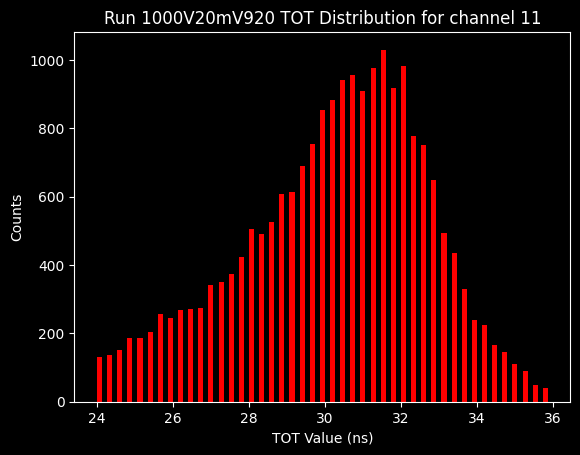

In [35]:
# plot tot distribution for the first active channel
plt.hist(data['tots'], bins=np.arange(24, 36, 2/15.), color='red')

plt.xlabel('TOT Value (ns)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} TOT Distribution for channel {channel}')
plt.savefig(f'I:/fd2_analyses/tot_distribution_run{run_name}_chan{channel:02d}_tot.png')
plt.show()

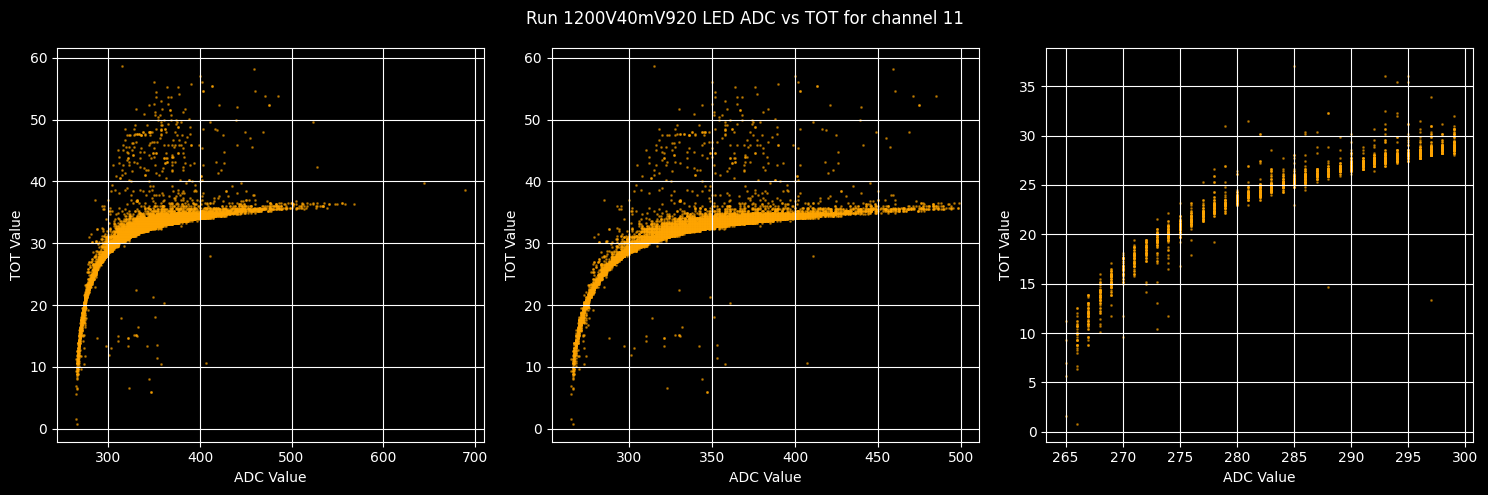

In [5]:
# show a scatter plot of ADC vs TOT. Show 3 subplots. the second one showing only ADC < 500, third ADC < 300
# optionally apply a requirement to select events consistent with an LED flashing
apply_mask = True

if apply_mask:
    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
else:
    mask_led = data['pmt_time_modulus_zeroeds'] != None  # all events

fig, ax = plt.subplots(1,3,figsize=(15, 5))

ax[0].scatter(data['adcs'][mask_led], data['tots'][mask_led], s=1, alpha=0.5, color='orange')
ax[0].set_xlabel('ADC Value')
ax[0].set_ylabel('TOT Value')
ax[0].grid(True)

mask_adc = data['adcs'][mask_led] < 500.
ax[1].scatter(data['adcs'][mask_led][mask_adc], data['tots'][mask_led][mask_adc], s=1, alpha=0.5, color='orange')
ax[1].set_xlabel('ADC Value')
ax[1].set_ylabel('TOT Value')
ax[1].grid(True)

mask_adc = data['adcs'][mask_led] < 300.
ax[2].scatter(data['adcs'][mask_led][mask_adc], data['tots'][mask_led][mask_adc], s=1, alpha=0.5, color='orange')
ax[2].set_xlabel('ADC Value')
ax[2].set_ylabel('TOT Value')
ax[2].grid(True)

if apply_mask:
    plt.suptitle(f'Run {run_name} LED ADC vs TOT for channel {channel}')
    extra='_LED'
else:
    plt.suptitle(f'Run {run_name} ADC vs TOT for channel {channel}')
    extra=''
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_vs_tot_run{run_name}_chan{channel:02d}{extra}.png')
plt.show()

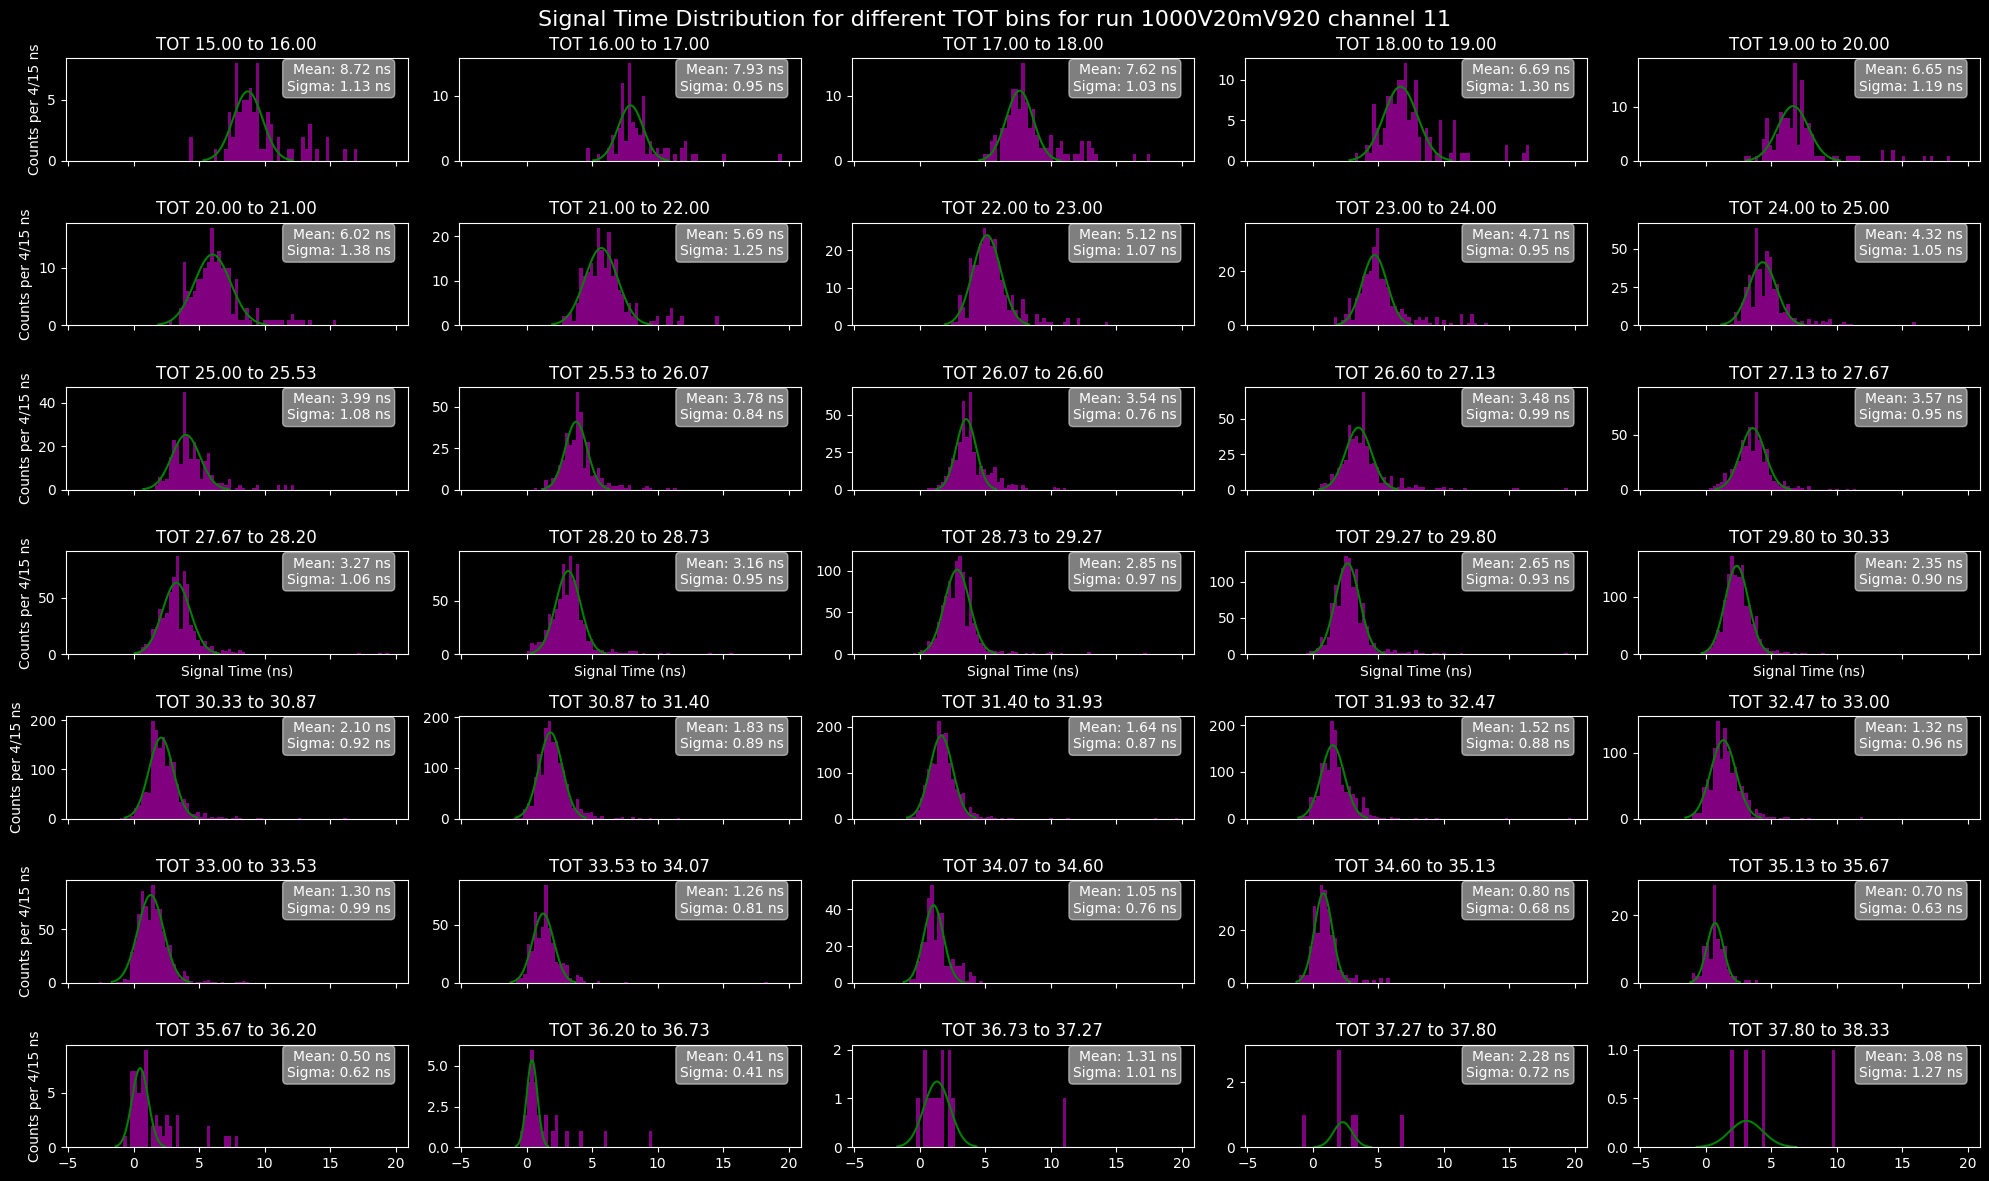

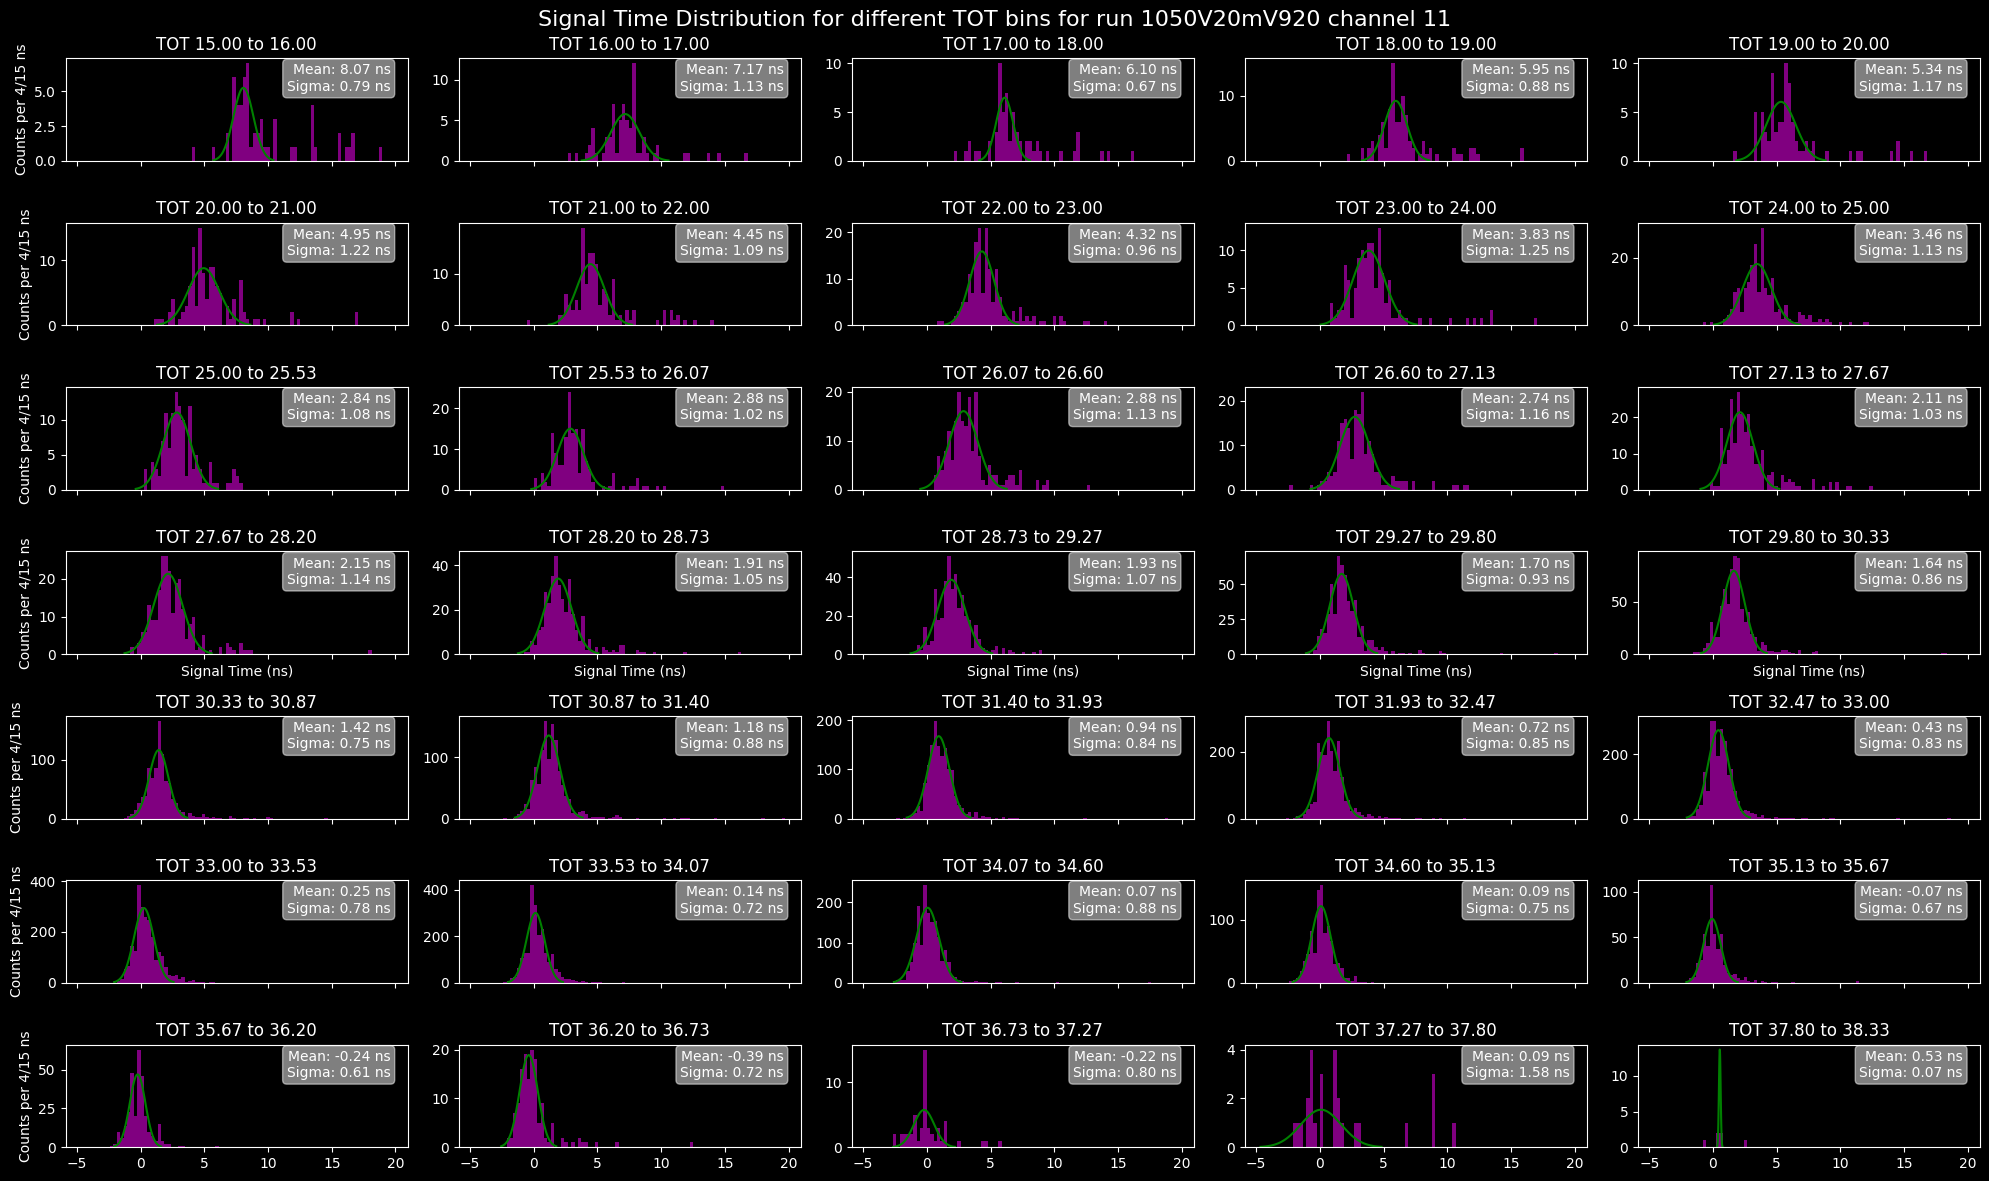

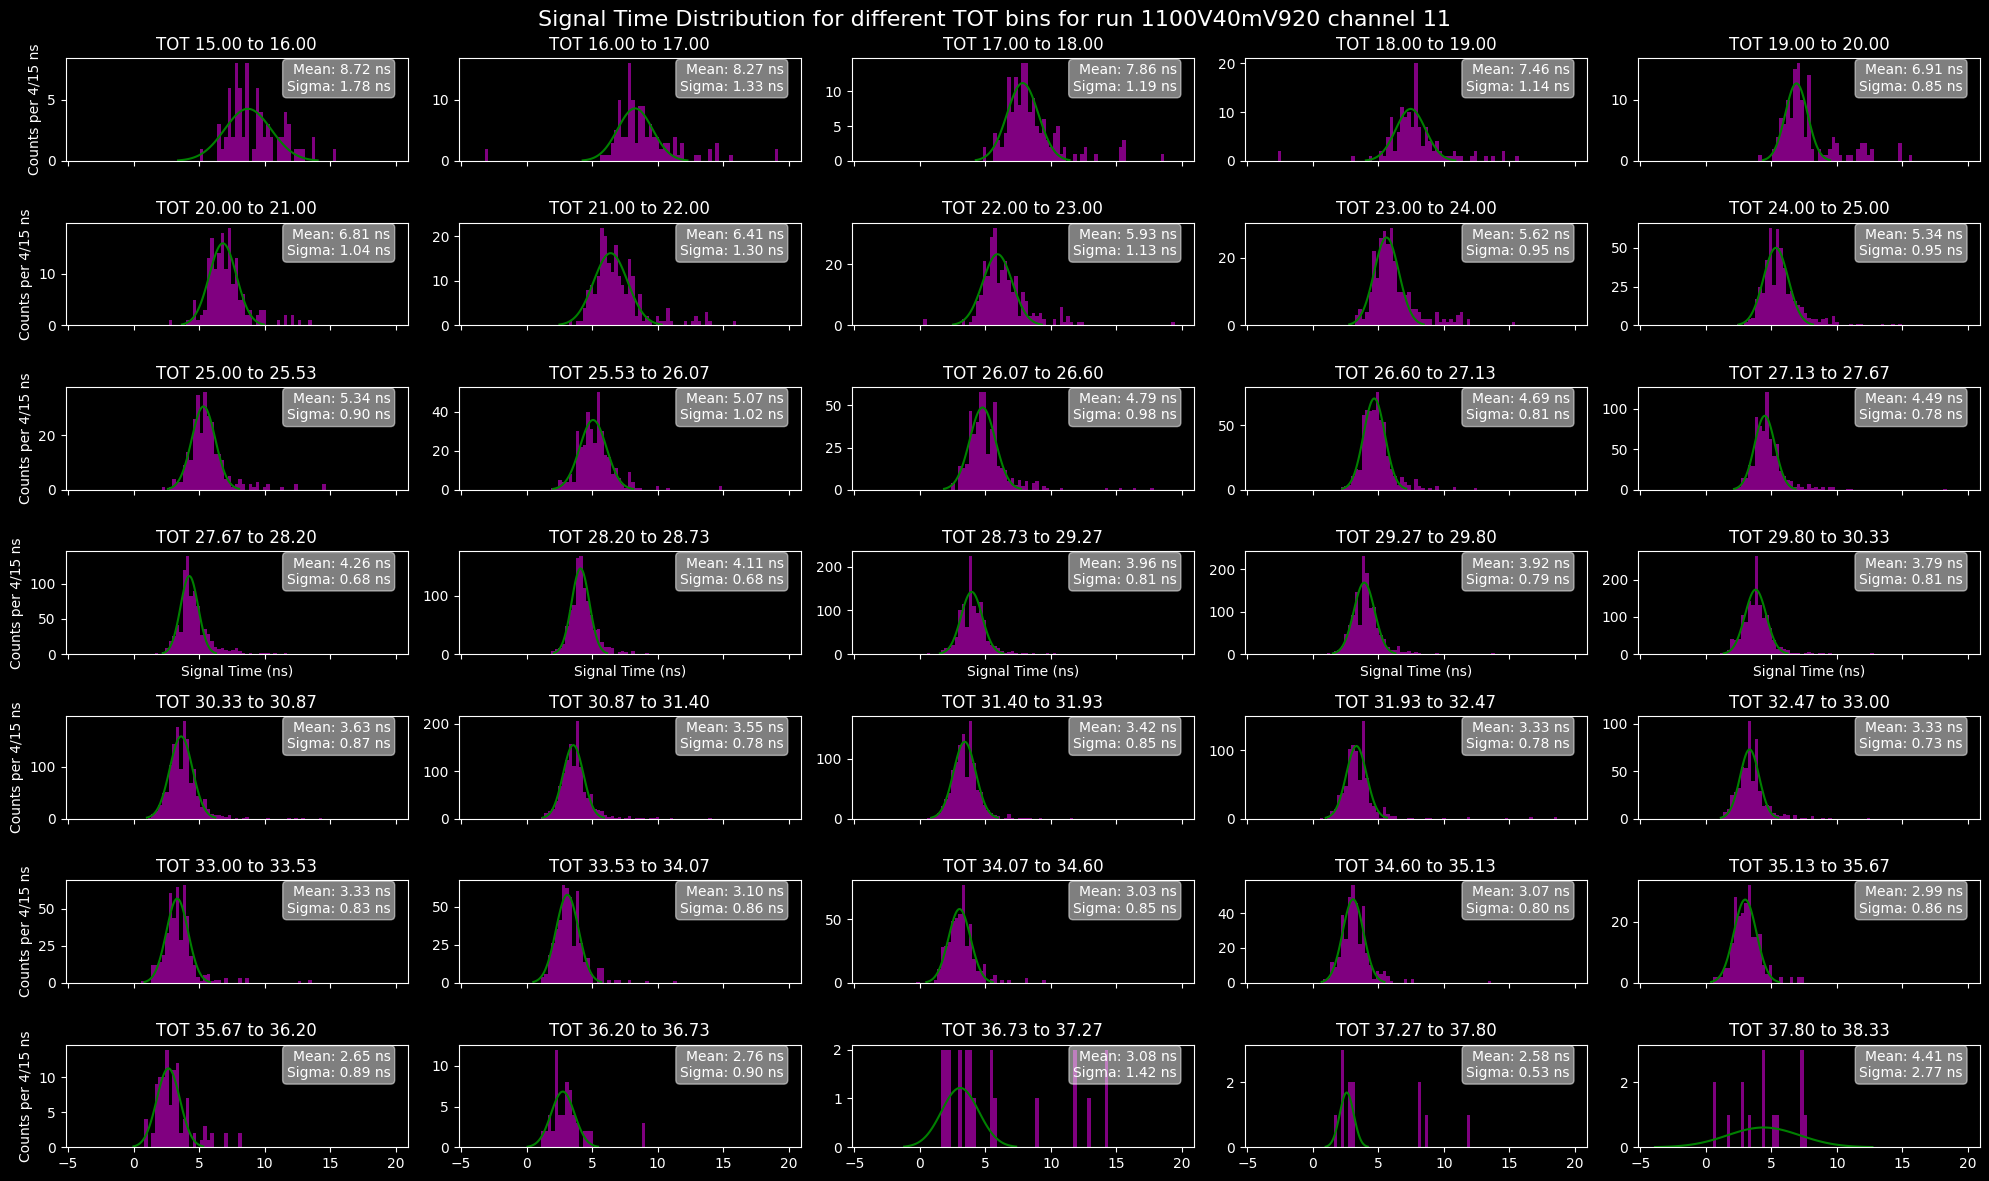

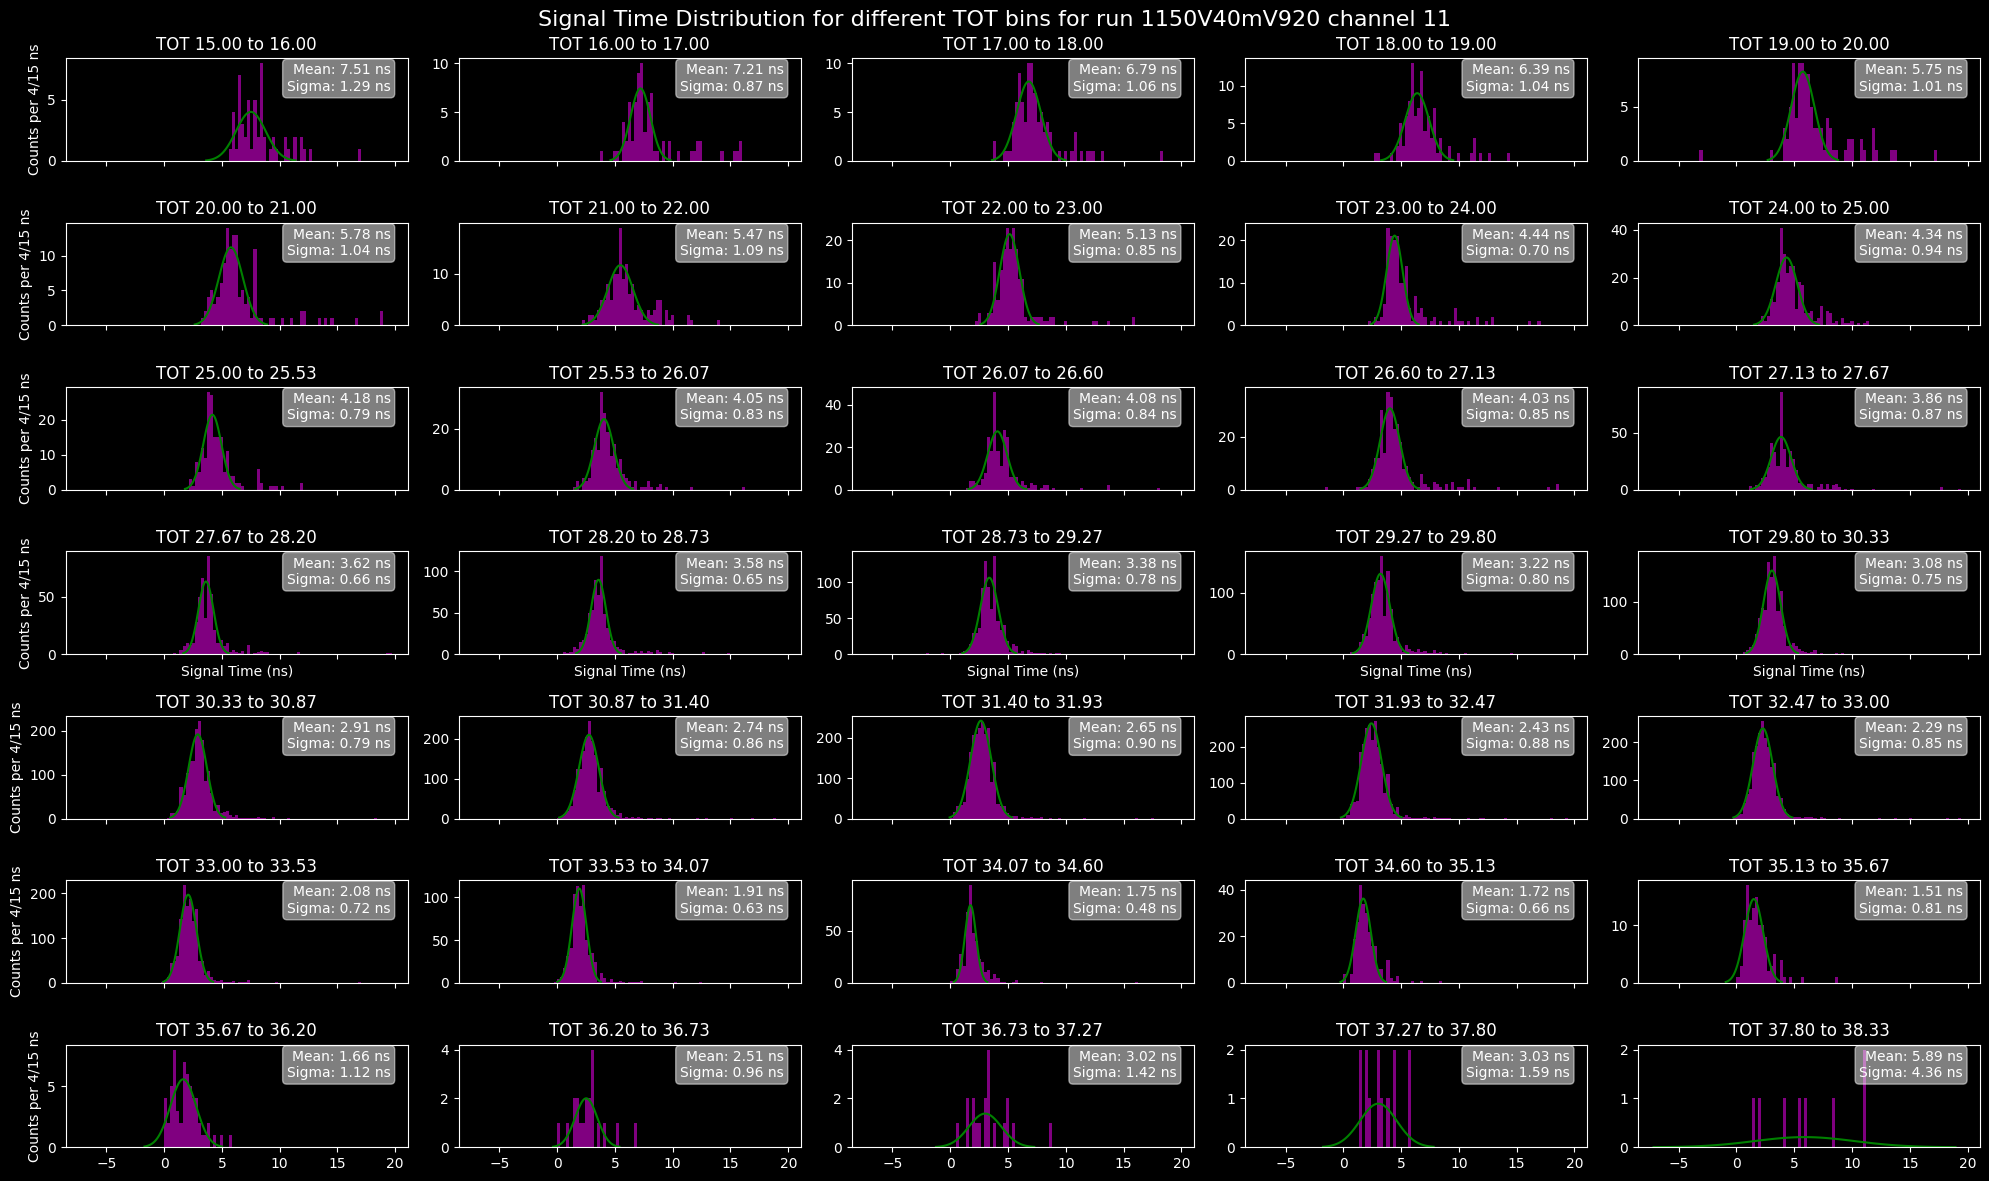

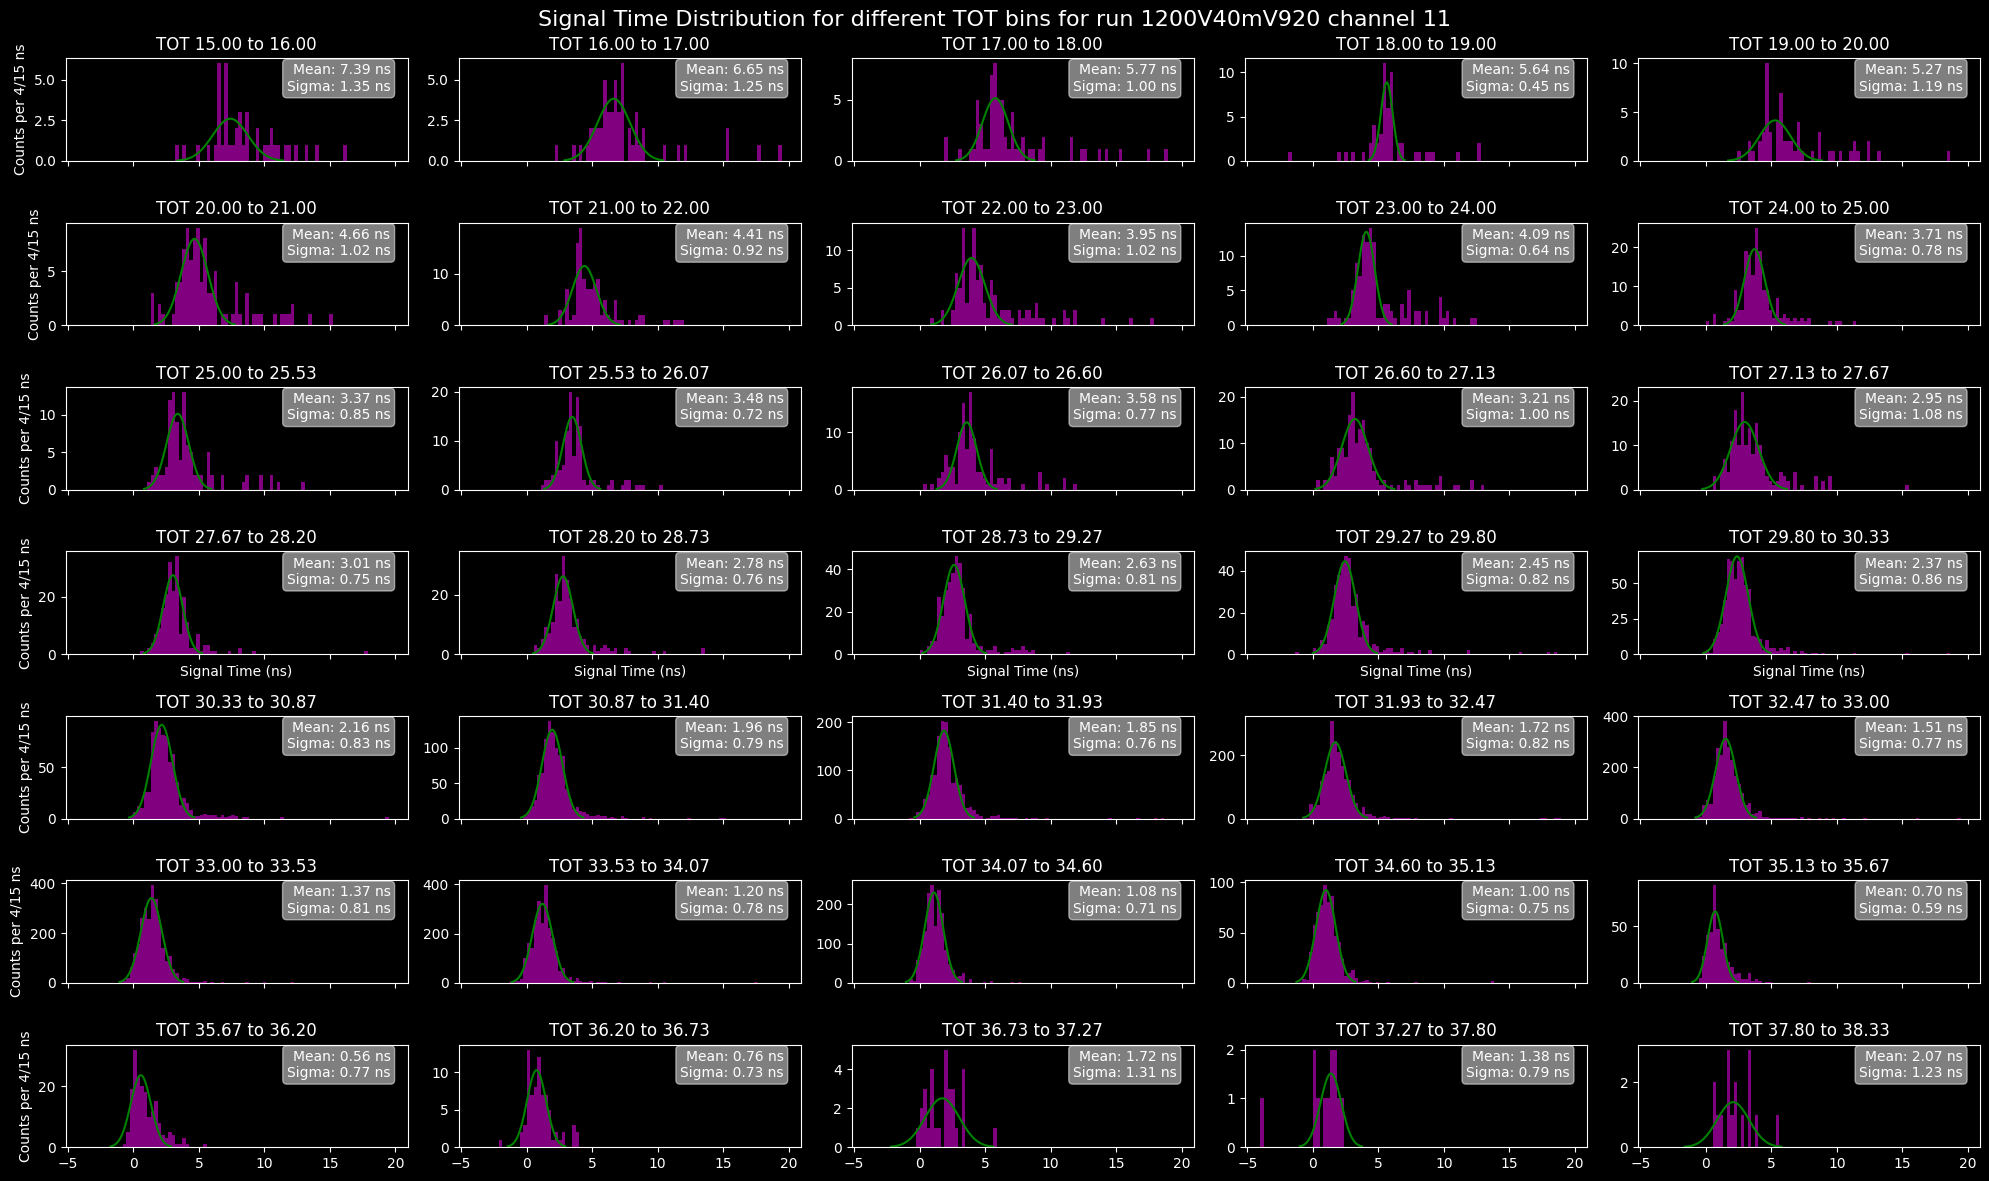

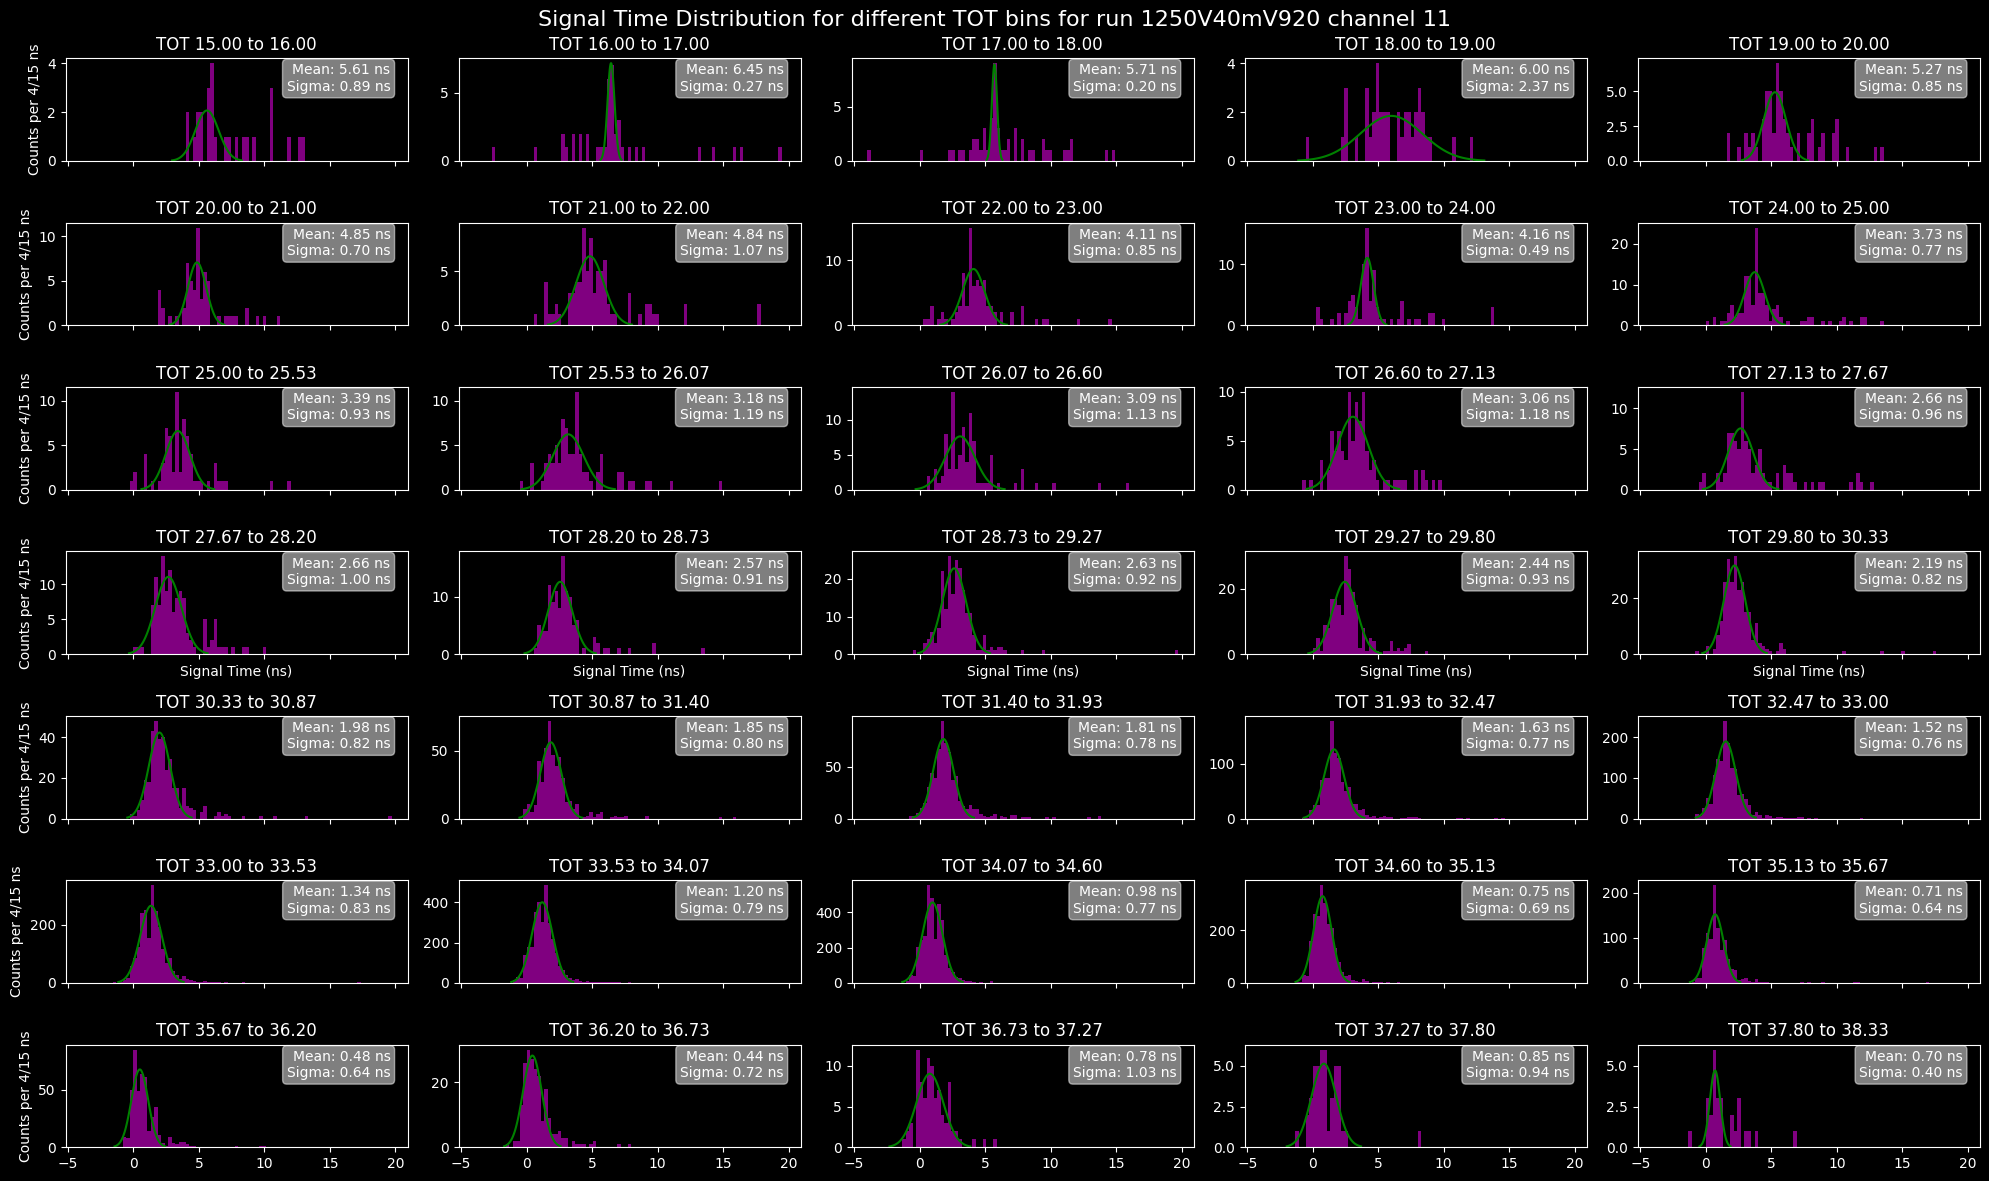

In [31]:
# The mean and standard deviation of the signal times will depend on the amplitude of the pulse.
# Look at the signal time distribution as a function of tot value, by considering bins of tot values.
# For each bin, plot the distribution of signal times, and fit to a Gaussian to extract the
# mean and standard deviation of the signal time for that tot bin.

time_walk_correction_funcs = {}
time_walk_correction_ranges = {}
time_walk_correction_means_sel = {}
time_walk_correction_stds_sel = {}
time_walk_correction_bin_centers_sel = {}

tot_offset = 0
tot_bin_min = 15

bin_width = 1
tot_bin_edges = [tot_bin_min]
for i in range(10):
    tot_bin_edges.append(tot_bin_edges[-1] + bin_width)
bin_width = 8/15 # matching tdc binning of 4/15
for i in range(25):
    tot_bin_edges.append(tot_bin_edges[-1] + bin_width)


for run_name in run_names:
    if 'V920' in run_name:
        channel = 11
        data = get_data(run_name=run_name, channel=channel)

        mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

        n_signal_times = []
        mean_signal_times = []
        std_signal_times = []

        # Make subplots in 4x5 grid, in each plot show the signal time distribution for a different TOT bin
        fig, ax = plt.subplots(7, 5, figsize=(20, 12), sharex=True)

        for i in range(len(tot_bin_edges)-1):
            axis = ax[i//5, i%5]
            bin = [tot_bin_edges[i]+tot_offset, tot_bin_edges[i+1]+tot_offset]
            mask_tot_bin = ((data['tots'] >= bin[0]) & (data['tots'] < bin[1]) & mask_led)
            signal_times_tot_bin = data['signal_times'][mask_tot_bin]
            axis.hist(signal_times_tot_bin, bins=np.arange(-4.,20.,4./15), color='purple')
            axis.set_title(f'TOT {bin[0]-tot_offset:0.2f} to {bin[1]-tot_offset:0.2f}')

            if i%5 == 0:
                axis.set_ylabel('Counts per 4/15 ns')
            if i//5 == 3:
                axis.set_xlabel('Signal Time (ns)')
            # Fit to a Gaussian
            if len(signal_times_tot_bin) > 0:
                hist, bin_edges = np.histogram(signal_times_tot_bin, bins=np.arange(-4.,20.,4./15))
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                # Initial guess for fit parameters: amplitude, mean, stddev
                p0 = [np.max(hist), np.mean(signal_times_tot_bin), np.std(signal_times_tot_bin)]
                try:
                    popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
                    n_signal_times.append(hist.sum())
                    mean_signal_times.append(popt[1])
                    std_signal_times.append(popt[2])
                    # Plot the fit
                    x_fit = np.linspace(popt[1]-3*popt[2], popt[1]+3*popt[2], 100)
                    y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
                    axis.plot(x_fit, y_fit, color='green', linestyle='-')
                    # Add a text box with mean and sigma values shown
                    textstr = '\n'.join((
                        f'Mean: {popt[1]:.2f} ns',
                        f'Sigma: {popt[2]:.2f} ns'))
                    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
                    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)
                except RuntimeError:
                    n_signal_times.append(0)
                    mean_signal_times.append(np.nan)
                    std_signal_times.append(np.nan)
            else:
                n_signal_times.append(0)
                mean_signal_times.append(np.nan)
                std_signal_times.append(np.nan)
        plt.suptitle(f'Signal Time Distribution for different TOT bins for run {run_name} channel {channel}', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'I:/fd2_analyses/time_vs_tot_run{run_name}_chan{channel:02d}.png')
        plt.show()

        tot_bin_centers_sel = []
        mean_signal_times_sel = []
        std_signal_times_sel = []
        fit_range = [-1,-1]
        for i in range(len(tot_bin_edges)-1):
            bin = [tot_bin_edges[i],tot_bin_edges[i+1]]
            if n_signal_times[i] > 100:
                tot_bin_centers_sel.append((bin[0]+bin[1])/2)
                mean_signal_times_sel.append(mean_signal_times[i])
                std_signal_times_sel.append(std_signal_times[i])
                if fit_range[0] < 0:
                    fit_range[0] = tot_bin_edges[i]
                fit_range[1] = tot_bin_edges[i+1]

        time_walk_correction_func = interp1d(tot_bin_centers_sel, mean_signal_times_sel, kind='cubic', fill_value='extrapolate')
        time_walk_correction_funcs[run_name] = time_walk_correction_func
        time_walk_correction_ranges[run_name] = fit_range
        time_walk_correction_means_sel[run_name] = mean_signal_times_sel
        time_walk_correction_stds_sel[run_name] = std_signal_times_sel
        time_walk_correction_bin_centers_sel[run_name] = tot_bin_centers_sel


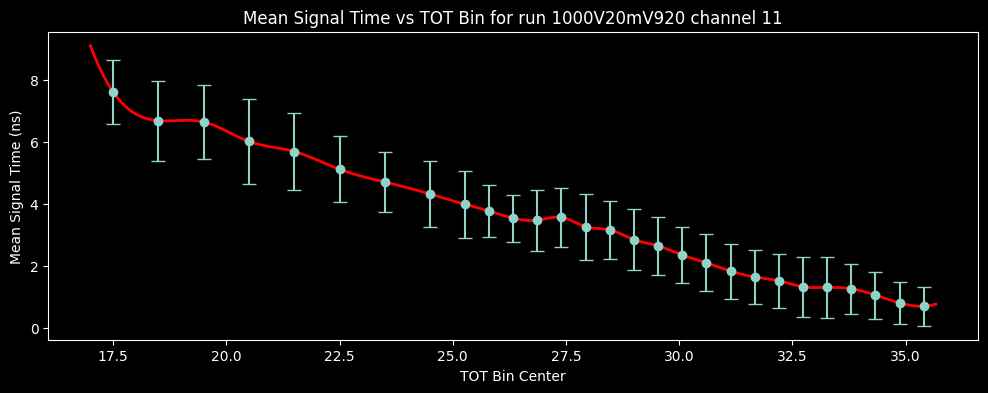

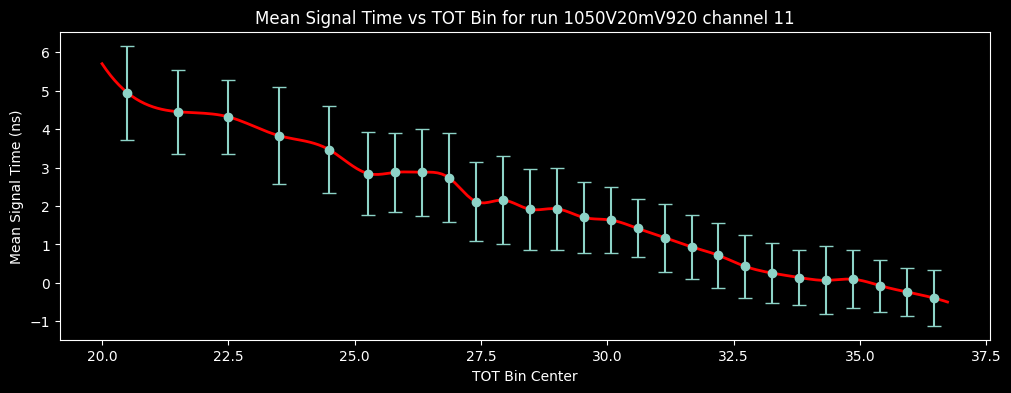

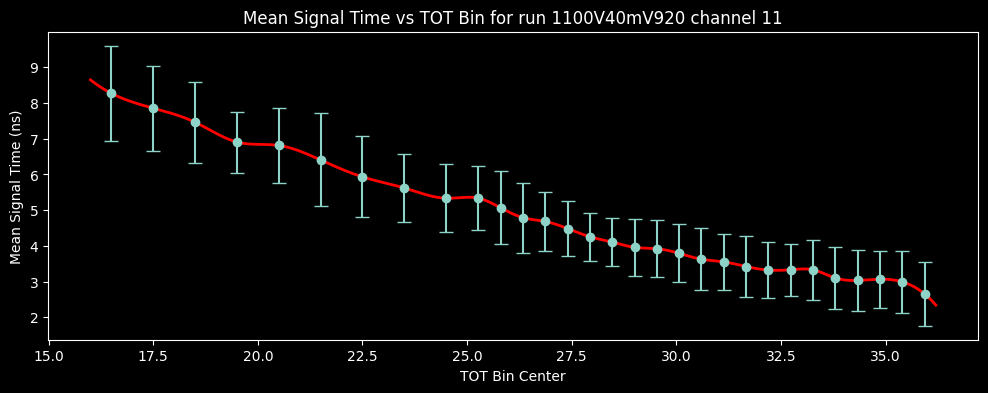

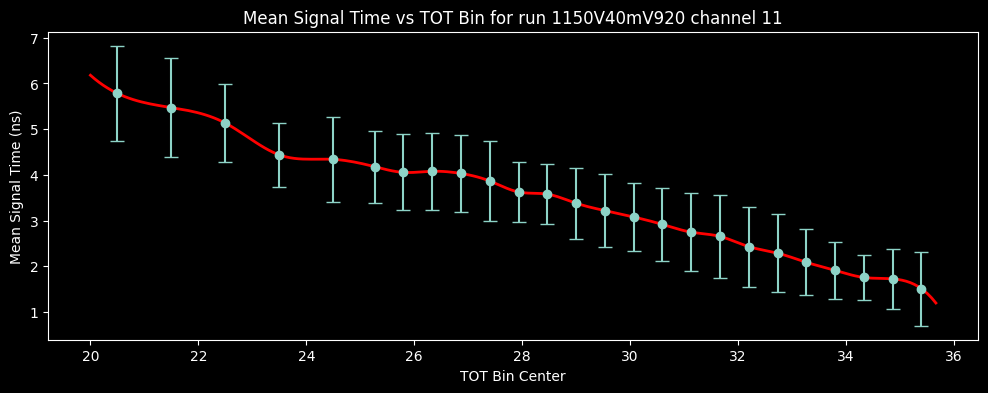

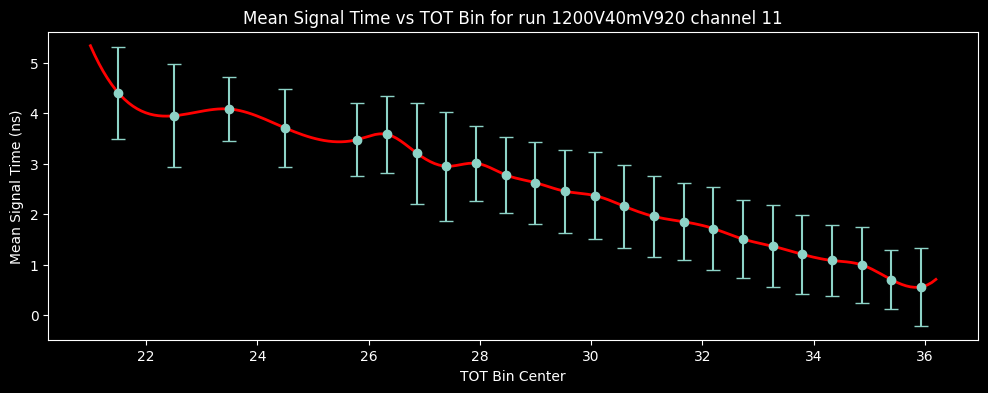

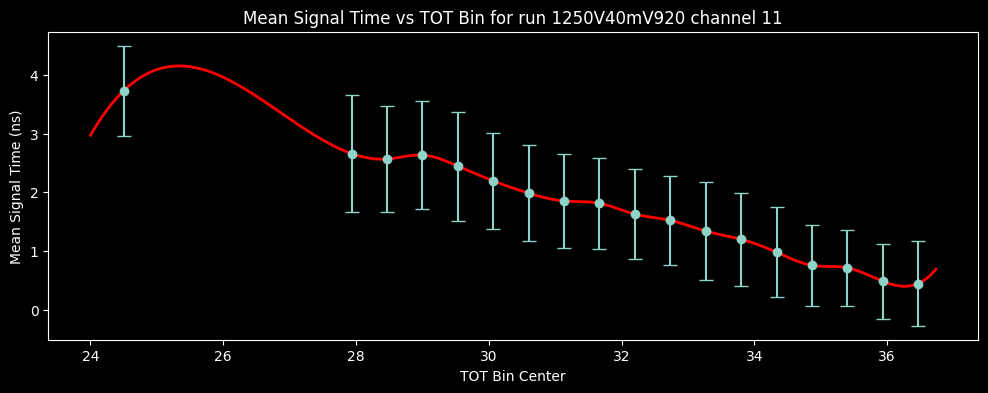

In [27]:
# Plot the mean signal time as a function of TOT bin, and show the standard deviation as error bars

for run_name in time_walk_correction_funcs.keys():

    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    mean_signal_times_sel = time_walk_correction_means_sel[run_name]
    std_signal_times_sel = time_walk_correction_stds_sel[run_name]
    tot_bin_centers_sel = time_walk_correction_bin_centers_sel[run_name]

    plt.figure(figsize=(12, 4))
    plt.errorbar(tot_bin_centers_sel, mean_signal_times_sel, yerr=std_signal_times_sel, fmt='o', capsize=5)
    x_fit = np.linspace(fit_range[0], fit_range[1], 200)
    y_fit = time_walk_correction_func(x_fit)
    plt.plot(x_fit, y_fit, color='red', linestyle='-', lw=2, label='Interpolation Function')

    plt.xlabel('TOT Bin Center')
    plt.ylabel('Mean Signal Time (ns)')
    plt.title(f'Mean Signal Time vs TOT Bin for run {run_name} channel {channel}')
    plt.savefig(f'I:/fd2_analyses/mean_signal_time_vs_tot_bin_run{run_name}_chan{channel:02d}.png')
    plt.show()

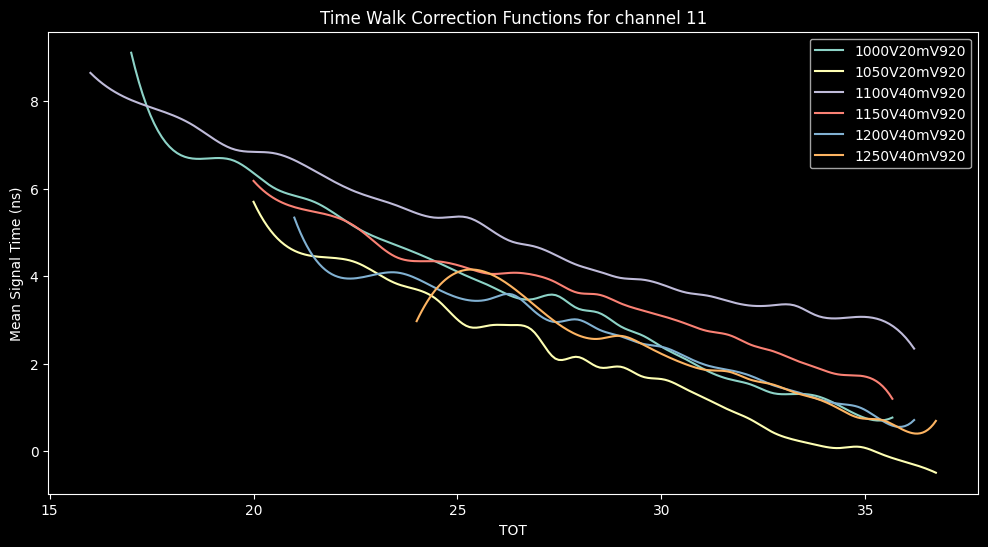

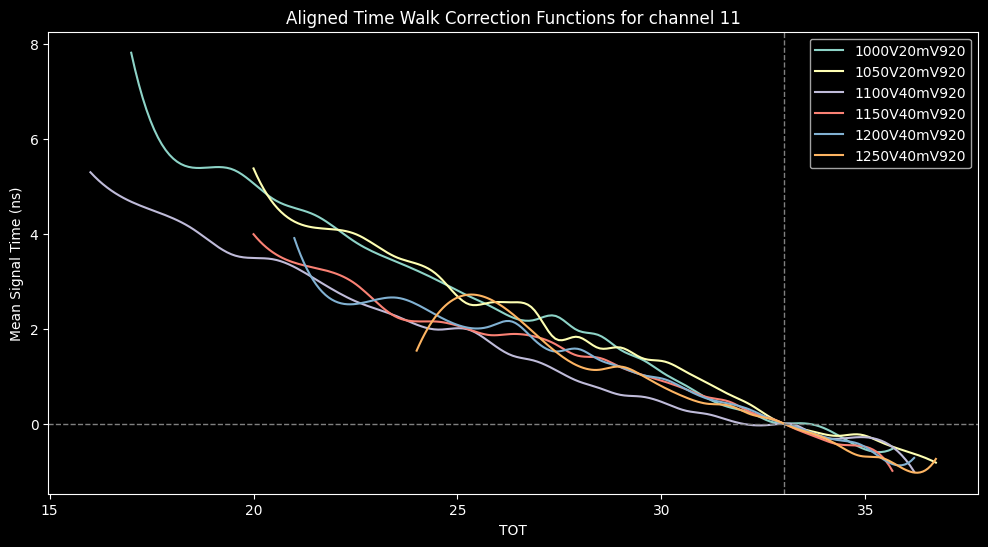

In [28]:
# Overlay the correction functions

# find correction factors to align all at t=0 at TOT = 33
offsets = {}
for run_name in time_walk_correction_funcs.keys():
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    offset = time_walk_correction_func(33)
    offsets[run_name] = offset

for i in range(2):  # with and without offset applied
    plt.figure(figsize=(12, 6))
    for run_name in time_walk_correction_funcs.keys():
        time_walk_correction_func = time_walk_correction_funcs[run_name]
        fit_range = time_walk_correction_ranges[run_name]

        x_fit = np.linspace(fit_range[0], fit_range[1], 200)
        y_fit = time_walk_correction_func(x_fit)
        if i==1:
            y_fit = time_walk_correction_func(x_fit) - offsets[run_name]
        plt.plot(x_fit, y_fit, label=f'{run_name}')
        plt.xlabel('TOT')
        plt.ylabel('Mean Signal Time (ns)')

    plt.legend()
    if i==0:
        plt.title(f'Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_tot.png')
    else:
        # add horizontal line at 0 and vertical line at 50:
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.axvline(33, color='gray', linestyle='--', linewidth=1)
        plt.title(f'Aligned Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_tot_aligned.png')
    plt.show()



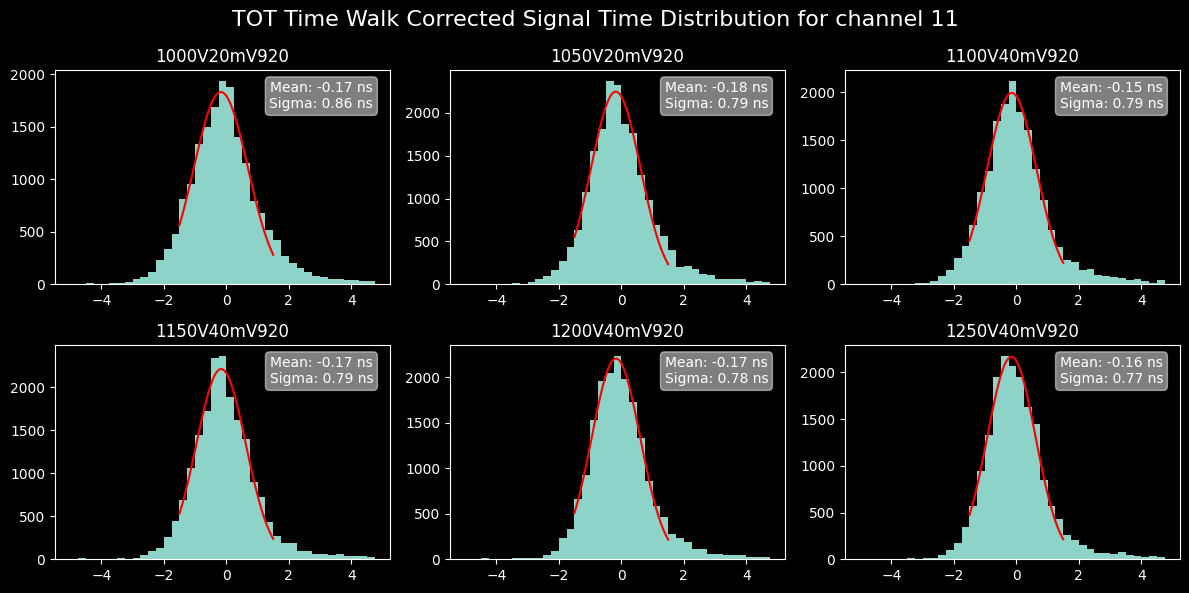

In [29]:
# Apply the time walk correction to the signal times, and show the distribution of signal times, use 2 rows and 3 columns

mean_cst = {}
std_cst = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6))
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

    corrected_signal_times = []
    for signal_time,tot in zip(data['signal_times'][mask_led],data['tots'][mask_led]):
        time_walk = time_walk_correction_func(tot-tot_offset)
        corrected_signal_times.append(signal_time - time_walk)

    axis.hist(corrected_signal_times,bins=np.arange(-5.,5.,0.25))
    axis.set_title(f'{run_name}')

    # fit the range from -1.5 to 1.5 to a Gaussian

    hist, bin_edges = np.histogram(corrected_signal_times, bins=np.arange(-1.5,1.5,0.25))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Initial guess for fit parameters: amplitude, mean, stddev
    p0 = [np.max(hist), 0, 1]

    popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
    mean_cst[run_name] = popt[1]
    std_cst[run_name] = abs(popt[2])
    # Plot the fit
    x_fit = np.linspace(-1.5, 1.5, 100)
    y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
    axis.plot(x_fit, y_fit, color='red', linestyle='-')
    # Add a text box with mean and sigma values shown
    textstr = '\n'.join((
        f'Mean: {popt[1]:.2f} ns',
        f'Sigma: {abs(popt[2]):.2f} ns'))
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)


plt.suptitle(f'TOT Time Walk Corrected Signal Time Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/corr_signal_time_distribution_chan{channel:02d}_tot.png')
plt.show()


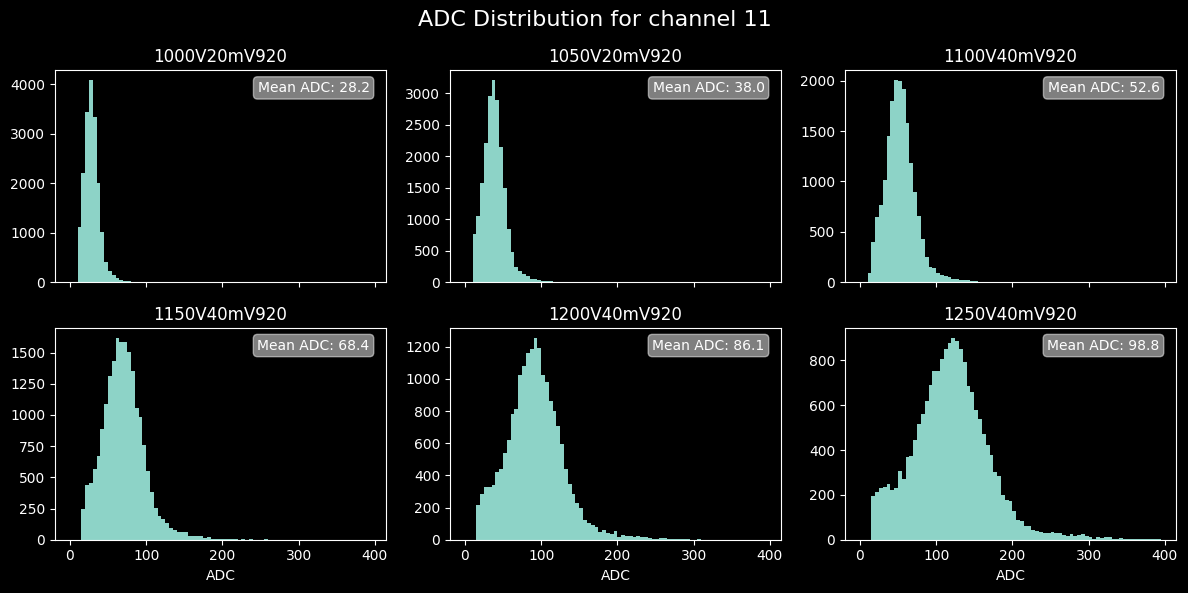

In [32]:
# Find the mean of the ADC distributions for the same runs to define the gains for each HV setting. Then plot the corrected signal time resolution (sigma from fit) as a function of gain.

adc_offset = 250
mean_adcs = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6), sharex=True)
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
    mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs']<400))
    axis.hist(data['adcs'][mask_led]-adc_offset,bins=np.arange(0,400,5))
    axis.set_title(f'{run_name}')
    if i>2:
        axis.set_xlabel('ADC')

    mean_adc = np.mean(data['adcs'][mask_adc]) - adc_offset
    mean_adcs[run_name] = mean_adc

    # Add a text box with mean shown
    textstr = f'Mean ADC: {mean_adc:.1f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)



plt.suptitle(f'ADC Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.show()



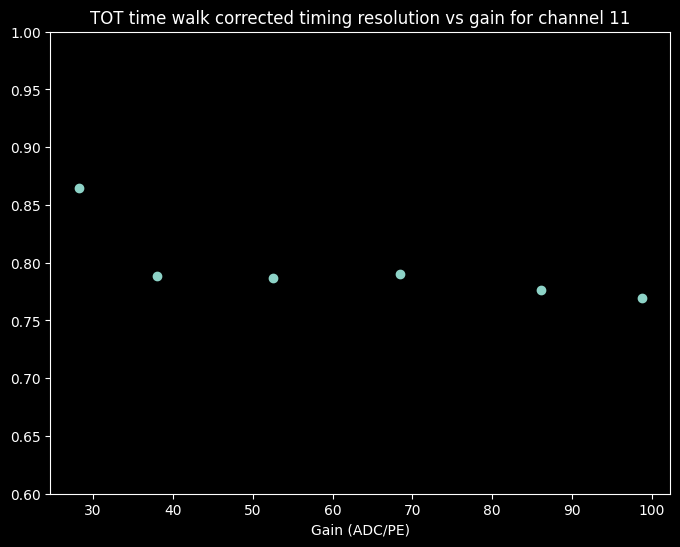

In [33]:
# Finally show the corrected signal time resolution as a function of mean ADC (gain proxy)

plt.figure(figsize=(8, 6))

gains = []
time_resols = []
for run_name in time_walk_correction_funcs.keys():
    gains.append(mean_adcs[run_name])
    time_resols.append(std_cst[run_name])

plt.plot(gains, time_resols, marker='o', linestyle=' ')
plt.xlabel('Gain (ADC/PE)')
plt.title(f'TOT time walk corrected timing resolution vs gain for channel {channel}')
plt.ylim(0.6,1.)
plt.savefig(f'I:/fd2_analyses/tot_timing_resolution_chan{channel:02d}.png')
plt.show()
